<a href="https://colab.research.google.com/github/gerdoc-unir/M1-ACT-1/blob/feature%2Falberto-leaky-relu/Actividad1_MODAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from typing import AnyStr, List
import os
from pathlib import Path
import shutil
import random
import tensorflow as tf

from tensorflow import keras

In [4]:
!rm -fr images

In [5]:
#Declaración de variables
path_img_tar: AnyStr = 'images.tar.gz'
path_annotations_tar: AnyStr = 'annotations.tar.gz'
path_img: AnyStr = 'images'
path_annotations: AnyStr = 'annotations'
cat_label: AnyStr = 'cat'
dog_label: AnyStr = 'dog'
train_label: AnyStr = 'train'
validation_label: AnyStr = 'validation'
test_label: AnyStr = 'test'
carpeta_img: Path = None
archivos: List = None
carpeta_train: Path = None
carpeta_validation: Path = None
carpeta_test: Path = None
archivos_gatos: List = None
archivos_perros: List = None
proporciones: List[float] = [0.8, 0.1, 0.1]
gatos_train:List = []
gatos_validation:List = []
gatos_test: List = []
perros_train:List = []
perros_validation:List = []
perros_test: List = []
IMG_HEIGHT = 160
IMG_WIDTH = 160
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
BATCH_SIZE = 32

In [6]:
#Validamos la separación sea correcta
assert abs(sum(proporciones) - 1.0) < 1e-9

In [7]:
#Descargando images
if not os.path.exists( path_img_tar ):
  print('Descargando imagenes...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_img_tar}')

#Descargando anotaciones
if not os.path.exists( path_annotations_tar ):
  print('Descargando anotaciones...')
  os.system(f'wget -c https://www.robots.ox.ac.uk/~vgg/data/pets/data/{path_annotations_tar}')

#Descompactando images
if os.path.exists( path_img_tar ) and not os.path.exists( path_img ):
  print('Descompactando imagenes...')
  os.system(f'tar -xf {path_img_tar}')
  carpeta_img: Path = Path( path_img )

#Descompactando anotaciones
if os.path.exists( path_annotations_tar ) and not os.path.exists( path_annotations ):
  print('Descompactando anotaciones...')
  os.system(f'tar -xf {path_annotations_tar}')


Descargando imagenes...
Descargando anotaciones...
Descompactando imagenes...
Descompactando anotaciones...


In [8]:
#Creación de carpetas
print('Creando carpetas de perros y gatos...')
if carpeta_img:
  archivos = list( carpeta_img.glob( "*.jpg" ) )
  print(f'Imagenes: {len(archivos)}' )
  carpeta_train = Path( f'{carpeta_img}/{train_label}' )
  carpeta_validation = Path( f'{carpeta_img}/{validation_label}' )
  carpeta_test = Path( f'{carpeta_img}/{test_label}' )
  carpetas: List[AnyStr] = [carpeta_train, carpeta_validation, carpeta_test]
  for carpeta in carpetas:
    if not os.path.exists( carpeta ):
      os.mkdir( carpeta )
      print( f'Creando {carpeta}' )
      os.mkdir( f'{carpeta}/{cat_label}' )
      print( f'Creando {carpeta}/{cat_label}' )
      os.mkdir( f'{carpeta}/{dog_label}' )
      print( f'Creando {carpeta}/{dog_label}' )

  if len( archivos ) > 0:
    archivos_gatos = []
    archivos_perros = []
    for archivo in archivos:
      if archivo.name[ 0 ].isupper( ):
        archivos_gatos.append( archivo )
      else:
        archivos_perros.append( archivo )
  if len( archivos_gatos ) > 0:
    print(f'Gatos: {len(archivos_gatos)}')
  if len( archivos_perros ) > 0:
    print(f'Perros: {len(archivos_perros)}')



Creando carpetas de perros y gatos...
Imagenes: 7390
Creando images/train
Creando images/train/cat
Creando images/train/dog
Creando images/validation
Creando images/validation/cat
Creando images/validation/dog
Creando images/test
Creando images/test/cat
Creando images/test/dog
Gatos: 2400
Perros: 4990


In [9]:
#Hacemos que se revuelvean los datos
random.seed( 42 )
random.shuffle( archivos_gatos )
random.shuffle( archivos_perros )

In [10]:
#Separamos los archivos en los distintos dataset
def dividir_archivos(archivos: List, proporciones: List[float]):
    total:int = len( archivos )
    limite_train:int = int(total * proporciones[0])
    limite_validation:int = limite_train + int(total * proporciones[1])
    train:List = archivos[:limite_train]
    validation: List = archivos[limite_train:limite_validation]
    test: List = archivos[limite_validation:]
    return train, validation, test

In [11]:
#Dataset de los archivos
gatos_train, gatos_validation, gatos_test = dividir_archivos( archivos_gatos, proporciones )
perros_train, perros_validation, perros_test = dividir_archivos( archivos_perros, proporciones )

In [12]:
#Movemos los archivos a las carpetas de los dataset
def mover_archivos(archivos:List, destino: AnyStr):
    for archivo in archivos:
        shutil.move( archivo, f'{destino}/{archivo.name}' )

In [13]:
#movemos los archivos a la estructura de la carpeta
mover_archivos( gatos_train, f'{carpeta_train}/{cat_label}' )
mover_archivos( perros_train, f'{carpeta_train}/{dog_label}')
mover_archivos( gatos_validation, f'{carpeta_validation}/{cat_label}')
mover_archivos( perros_validation, f'{carpeta_validation}/{dog_label}' )
mover_archivos( gatos_test, f'{carpeta_test}/{cat_label}' )
mover_archivos( perros_test, f'{carpeta_test}/{dog_label}' )

In [14]:
#Cargamos a keras el dataset
train_ds = keras.utils.image_dataset_from_directory( carpeta_train, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
validation_ds = keras.utils.image_dataset_from_directory( carpeta_validation, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
test_ds = keras.utils.image_dataset_from_directory( carpeta_test, image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="binary", shuffle=True )
print( train_ds.class_names )

Found 5912 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
Found 739 files belonging to 2 classes.
['cat', 'dog']


In [15]:
#Verificamos el tamaño de las imágenes
for imagenes, etiquetas in train_ds.take( 1 ):
    print( "Imágenes:", imagenes.shape)
    print( "Etiquetas:", etiquetas.shape)

Imágenes: (32, 160, 160, 3)
Etiquetas: (32, 1)


In [16]:
# Importando layers de keras
from tensorflow.keras import layers

In [17]:
# Normalizando pixeles
normalizacion = layers.Rescaling(1.0/ 255)
train_ds = train_ds.map(lambda x, y: (normalizacion(x), y))
validation_ds = validation_ds.map(lambda x, y: (normalizacion(x), y))

# Mejora de rendimiento
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)
validation_ds = validation_ds.prefetch(tf.data.AUTOTUNE)

# Creación de Modelo
input_shape = (IMG_WIDTH, IMG_HEIGHT, 3)
alpha=0.1
modelo = keras.Sequential([
    layers.Input(shape=input_shape),

    layers.Conv2D(32, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same"),
    layers.LeakyReLU(alpha=alpha),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(512),
    layers.LeakyReLU(alpha=alpha),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [18]:
# Comienza entrenamiento de LeakyReLU
modelo.summary()

historial = modelo.fit(train_ds, validation_data=validation_ds, epochs=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 160, 160, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 80, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 40, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,554,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,795,457 (25.92 MB)

 Trainable params: 6,795,457 (25.92 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.6710 - loss: 0.6325 - val_accuracy: 0.6752 - val_loss: 0.5836
Epoch 2/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 250s 1s/step - accuracy: 0.6999 - loss: 0.5634 - val_accuracy: 0.7686 - val_loss: 0.5259
Epoch 3/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 267s 1s/step - accuracy: 0.7515 - loss: 0.5027 - val_accuracy: 0.7889 - val_loss: 0.4541
Epoch 4/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.7977 - loss: 0.4417 - val_accuracy: 0.8254 - val_loss: 0.4017
Epoch 5/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.8263 - loss: 0.3838 - val_accuracy: 0.8241 - val_loss: 0.3973
Epoch 6/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 0.8692 - loss: 0.3045 - val_accuracy: 0.8363 - val_loss: 0.3954
Epoch 7/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 262s 1s/step - accuracy: 0.9056 - loss: 0.2267 - val_accuracy: 0.8349 - val_loss: 0.4766
Epoch 8/10
185/185 ━━━━━━━━━━━━━━━━━━━━ 266s 1s/step - accuracy: 0.9383 - loss: 0.1510 - val_accu

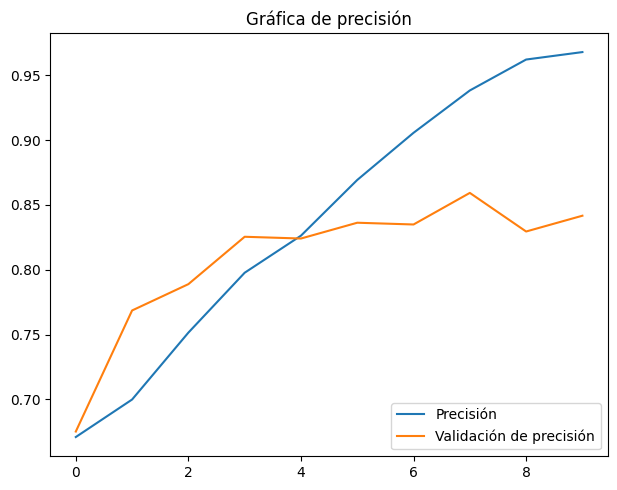

In [20]:
# Se procede a la graficación de los resultados
import matplotlib.pyplot as plt

acc = historial.history['accuracy']
val_acc = historial.history['val_accuracy']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

# Gráfica de precisión
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Precisión")
plt.plot(epochs_range, val_acc, label="Validación de precisión")
plt.legend(loc="lower right")
plt.title("Gráfica de precisión")

plt.tight_layout()
plt.show()